In [133]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [134]:
data = pd.read_csv("/content/Mall_Customers.csv")

In [135]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [136]:
x = data[["Annual Income (k$)","Spending Score (1-100)"]]

In [137]:
scalar = StandardScaler()
X = scalar.fit_transform(x)

In [138]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


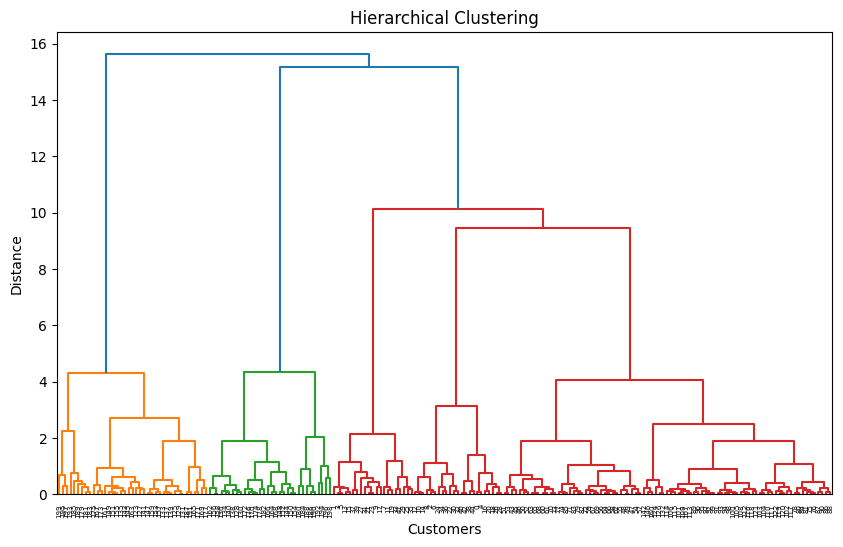

In [139]:
plt.figure(figsize=(10,6))
dendrogram(
    linkage(
        X,
        method="ward"
    )
)
plt.title("Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [140]:
model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)
labels = model.fit_predict(X)

In [141]:
data["Clusters"] = labels

In [142]:
data


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,0


In [143]:
print(data["Clusters"].value_counts())

Clusters
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64


In [144]:
print(data.groupby("Clusters").mean(numeric_only=True))

          CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Clusters                                                                   
0         166.250000  41.000000           89.406250               15.593750
1         162.000000  32.692308           86.538462               82.128205
2          87.894118  42.482353           55.811765               49.129412
3          22.000000  25.333333           25.095238               80.047619
4          23.000000  45.217391           26.304348               20.913043


In [145]:
print(silhouette_score(x,labels))

0.5529945955148897
